In [ ]:
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

# **Preparing The Dataset**

In [ ]:
columns = ["Age","Sex","ChestPainType", "RestingBP","Cholesterol","FastingBS","RestingECG","MaxHR","ExerciseAngina","Oldpeak","ST_Slope","HeartDisease"]
# df = pd.read_csv("heart.csv", names=columns, header=0)

# This will load dataset directly from Kaggle
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "fedesoriano/heart-failure-prediction",
  "heart.csv",
)

print("Dataframe shape : ",df.shape)
df.head()

Dataframe shape :  (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# **Cleaning The Dataset**

In [3]:
df["Cholesterol"] = df["Cholesterol"].replace(0, df["Cholesterol"].median())
df["RestingBP"] = df["RestingBP"].replace(0, df["RestingBP"].median())

In [4]:
# Removing rows with missing values
df = df.dropna(subset=["Age","Sex","ChestPainType", "RestingBP","Cholesterol","FastingBS","RestingECG","MaxHR","ExerciseAngina","Oldpeak","ST_Slope","HeartDisease"])

# Encoding Categorical columns
cat_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=cat_columns, drop_first=False)

# Data frame shape after encoding
print("Dataframe shape : ",df_encoded.shape)

# Columns after encoding
print("Columns : ",df_encoded.columns)

Dataframe shape :  (918, 21)
Columns :  Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


# **Class Distribution of the Dataset**

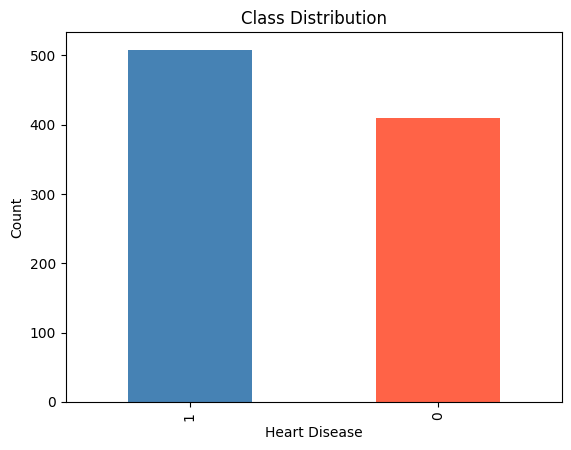

In [19]:
df["HeartDisease"].value_counts().plot(kind="bar", color=["steelblue","tomato"])
plt.title("Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

# **Applying SMOTE (Since The Dataset is Imbalanced)**

In [6]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

In [7]:
X = df_encoded.drop("HeartDisease",axis=1)
y = df_encoded["HeartDisease"]

In [8]:
# Splitting the dataset before SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [10]:
print("Before SMOTE : ", Counter(y_train))
print("After SMOTE : ",Counter(y_train_resampled))

Before SMOTE :  Counter({1: 401, 0: 333})
After SMOTE :  Counter({0: 401, 1: 401})


# **Class Distribution After Applying SMOTE**

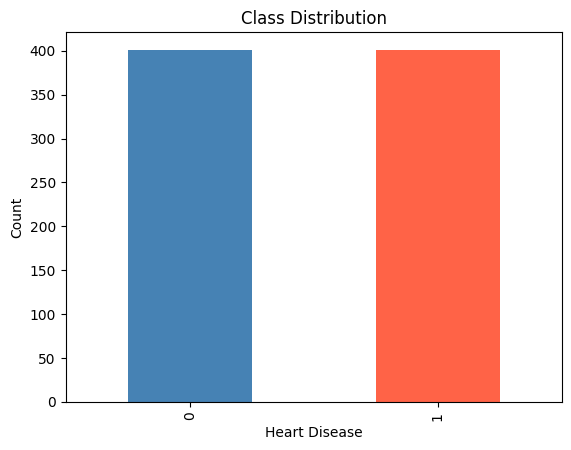

In [30]:
y_train_resampled.value_counts().plot(kind="bar", color=["steelblue","tomato"])
plt.title("Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

# **Model Creation and Training**

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [32]:
# Initializing the model
random_forest_model = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight="balanced"
)

# Train the model using SMOTE data
random_forest_model.fit(X_train_resampled, y_train_resampled)

y_pred = random_forest_model.predict(X_test)

In [33]:
# Accuracy of Random Forest Model for the dataset
print("Accuracy : ", accuracy_score(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy :  0.8532608695652174
              precision    recall  f1-score   support

           0       0.81      0.84      0.83        77
           1       0.88      0.86      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

